In [1]:
import numpy as np

import matplotlib.pyplot as plt

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

from astroML.classification import GMMBayes
from astroML.datasets import fetch_rrlyrae_combined
from astroML.utils import split_samples

from scipy.stats import norm


from astropy.io import ascii
from astropy.io import fits
import os.path

from astropy.table import Table, join, MaskedColumn, vstack, Column


import numpy as np
from astropy.table import vstack
import torch

import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [64]:
print('hi')

hi


In [11]:
import sys, os

# Ensure GenerateTable_CGW is on the path so sub-packages resolve
MODULE_DIR = os.path.dirname(os.path.abspath('generate_table.ipynb'))
if MODULE_DIR not in sys.path:
    sys.path.insert(0, MODULE_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = '../data'
LC_DIR   = '../light_curves'
OUTPUT   = '../GenerateTable_CGW/cluster_table_1sector2cadence_per_cluster.fits'

In [12]:
print('MODULE_DIR: ', MODULE_DIR)
print('DATA_DIR  : ', DATA_DIR)
print('LC_DIR    : ', LC_DIR)
print('OUTPUT    : ', OUTPUT)

MODULE_DIR:  /astro/users/cgwill/TESS_Cluster_Age_ML/PCA_CGW
DATA_DIR  :  ../data
LC_DIR    :  ../light_curves
OUTPUT    :  ../GenerateTable_CGW/cluster_table_1sector2cadence_per_cluster.fits


In [13]:
import ast
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table


# _DROP_COLS = ['gp_result', 'GP_PSD_binned', 'GP_PSD_bin_ratios']
# _ARRAY_COLS = ['LC_t', 'LC_flux', 'LC_flux_err', 'LSP_freq', 'LSP_power', 'GP_freq', 'GP_PSD']


# def save_as_fits(df, path):
#     """Save cluster table DataFrame to a FITS binary table."""
#     df = df.copy()

#     df = df.drop(columns=[c for c in _DROP_COLS if c in df.columns])

#     # sectors list → string (lists are object dtype, not FITS-compatible)
#     if 'sectors' in df.columns:
#         df['sectors'] = df['sectors'].apply(str)

#     # Coerce None/object array cells to numpy float64 (None → empty array)
#     for col in _ARRAY_COLS + ['gp_periods']:
#         if col not in df.columns:
#             continue
#         df[col] = df[col].apply(
#             lambda x: np.array([], dtype=np.float64) if x is None
#                       else np.asarray(x, dtype=np.float64).ravel()
#         )

#     Table.from_pandas(df).write(path, format='fits', overwrite=True)
#     print(f"[fits_io] saved {len(df)} rows → {path}")


def load_from_fits(path):
    """Load cluster table from FITS, returning a pandas DataFrame.

    Uses astropy.io.fits directly because Table.to_pandas() silently NaN-ifies
    variable-length array (PD) columns.
    """
    _fmt_dtype = {'D': np.float64, 'E': np.float32, 'K': np.int64,
                  'J': np.int32, 'I': np.int16, 'L': np.bool_}

    with fits.open(path) as hdul:
        hdu  = hdul[1]
        data = hdu.data
        n    = len(data)

        rows = {}
        for col in hdu.columns:
            name = col.name
            fmt  = col.format
            raw  = data[name]

            if fmt.startswith('P'):
                rows[name] = [np.array(raw[i], dtype=np.float64) for i in range(n)]
            elif 'A' in fmt:
                rows[name] = [
                    v.decode('utf-8').strip() if isinstance(v, bytes) else str(v).strip()
                    for v in raw
                ]
            else:
                dtype = _fmt_dtype.get(fmt.lstrip('0123456789'), np.float64)
                rows[name] = np.array(raw, dtype=dtype)

    df = pd.DataFrame(rows)

    if 'sectors' in df.columns:
        df['sectors'] = df['sectors'].apply(ast.literal_eval)

    print(f"[fits_io] loaded {len(df)} rows from {path}")
    return df


In [15]:
#from table_pipeline.fits_io import save_as_fits, load_from_fits

# Save feature table (no gp_result) as FITS — loadable anywhere without custom imports
#FITS_OUTPUT = OUTPUT.replace('.pkl', '.fits')
#save_as_fits(table, FITS_OUTPUT)
#print(f"Columns: {list(table.columns)}")

# --- Loading examples ---
# Load from FITS (no custom imports needed):
table = load_from_fits(OUTPUT)


[fits_io] loaded 602 rows from ../GenerateTable_CGW/cluster_table_1sector2cadence_per_cluster.fits


In [16]:
table

,name,age,origin,sectors,n_sectors,cadence,LC_t,LC_flux,LC_flux_err,LSP_freq,...,GP_PSD_high_low_ratio,gp_n_components,gp_bic,gp_log_likelihood,gp_periods,gp_kspace_bin_edges,gp_kspace_bin_centers,gp_kspace_log_band_powers,gp_kspace_log_low_high_ratio,gp_kspace_log_band_ratios
0,ASCC 116,7.95,MW,[0],1,30.00,"[1738.6806030273438, 1738.701416015625, 1738.7...","[1.000039172302579, 1.000780081169836, 1.00091...","[2.0657422001480668e-05, 2.0656997686743e-05, ...","[0.1030038601300122, 0.1081540531365128, 0.113...",...,-0.020265,1.0,-13056.628026,6541.995106,[0.9154369791627075],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-8.244915287198383, -8.077211288729776, -7.85...",-0.007953,"[-0.16770399846885128, -0.2177630885918673, -0..."
1,ASCC 116,7.95,MW,[3],1,3.33,"[2853.367327445016, 2853.388160748298, 2853.40...","[1.002411578761114, 1.0011820364092294, 1.0003...","[2.0753927710833995e-05, 2.0753735660051478e-0...","[0.1, 0.10391203511753488, 0.10782407023506978...",...,0.097654,1.0,-18352.165602,9190.254604,[1.1483642336101665],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.711195096029857, -7.548189204830307, -7.34...",0.110365,"[-0.16300589119961917, -0.2064316416812007, -0..."
2,ASCC 57,9.26,MW,[0],1,30.00,"[1596.8043991770023, 1596.82523238681, 1596.84...","[1.0001676189326913, 1.0002198336564603, 1.000...","[2.41546050697253e-05, 2.4513031844638225e-05,...","[0.1, 0.10385546039649415, 0.10771092079298829...",...,-0.130602,1.0,-18972.655450,9500.474265,[0.7409469485151726],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.404633183765482, -9.2340646573969, -9.0092...",-0.118542,"[-0.1705685263721625, -0.2248503494333464, -0...."
3,ASCC 57,9.26,MW,[1],1,10.00,"[2280.914927407121, 2280.9357611011706, 2280.9...","[0.9995608247646004, 0.9996663848790217, 0.999...","[3.4129678916826896e-05, 3.453160463354713e-05...","[0.1, 0.10399219299907575, 0.1079843859981515,...",...,0.052838,1.0,-18681.451825,9354.824422,[1.0531788371888893],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.036789556587289, -8.871745869625153, -8.66...",0.065381,"[-0.1650436869636305, -0.21130173127994234, -0..."
4,ASCC 8,7.77,MW,[0],1,30.00,"[1790.68108820474, 1790.7019220787656, 1790.72...","[0.9994443476985684, 1.0001088391105897, 1.000...","[1.4396824247785199e-05, 1.4391031036191415e-0...","[0.1, 0.10429334303634115, 0.10858668607268229...",...,-0.427762,1.0,-16513.199777,8270.611467,[0.5210742670894506],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.450988805343632, -9.271615771355375, -9.02...",-0.416582,"[-0.17937303399240806, -0.24700242921176954, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,[SL63] 76,8.10,LMC,[15],1,10.00,"[2361.7818528790162, 2361.8026865332045, 2361....","[0.9953471995762466, 0.9969531314613751, 0.998...","[0.00040806099720773313, 0.000408304620441091,...","[0.1, 0.10372763546968247, 0.10745527093936495...",...,1.105717,4.0,-15518.255166,7805.652864,"[3.4211448277334817, 1.8084278462574679, 0.744...","[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.882600972590979, -7.218256282493813, -6.25...",1.037906,"[-0.6643446900974261, -0.9634531363205994, 0.0..."
598,[SL63] 763,8.00,LMC,[5],1,30.00,"[1624.9696703914797, 1624.9905039559444, 1625....","[0.9980329509294824, 0.9988828393471748, 1.000...","[0.0005236888869231121, 0.0005508757996684755,...","[0.1, 0.10372956472537859, 0.10745912945075715...",...,0.434207,2.0,-13663.310626,6856.568370,"[3.3150770832980223, 0.634482819938877]","[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.349255588029251, -7.1439809322760395, -

In [56]:
table.columns

Index(['name', 'age', 'origin', 'sectors', 'n_sectors', 'cadence', 'LC_t',
       'LC_flux', 'LC_flux_err', 'LSP_freq', 'LSP_power', 'LSP_FAP',
       'LSP_WN_threshold', 'rn_log10_N', 'rn_alpha', 'rn_P_empirical',
       'rn_P_theoretical', 'intrinsic_std', 'intrinsic_rms', 'intrinsic_mad',
       'n_bins_used', 'vn_ratio_gap_aware', 'stetson_j_gap_aware', 'GP_freq',
       'GP_PSD', 'GP_PSD_high_low_ratio', 'gp_n_components', 'gp_bic',
       'gp_log_likelihood', 'gp_periods', 'gp_kspace_bin_edges',
       'gp_kspace_bin_centers', 'gp_kspace_log_band_powers',
       'gp_kspace_log_low_high_ratio', 'gp_kspace_log_band_ratios'],
      dtype='str')

In [19]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- scalar features ---
scalar_cols = [
    #'n_sectors', 'cadence',
    #'LSP_FAP', 'LSP_WN_threshold',
    #'rn_log10_N', 
    'rn_alpha', 
    #'rn_P_empirical', 
    #'rn_P_theoretical',
    'intrinsic_std', 
    'intrinsic_rms', 
    'intrinsic_mad',
    #'n_bins_used', 
    'vn_ratio_gap_aware', 
    'stetson_j_gap_aware',
    'GP_PSD_high_low_ratio',
    #'gp_n_components', 
    #'gp_bic', 
    #'gp_log_likelihood',
    'gp_kspace_log_low_high_ratio',
]

# --- array-valued columns to expand into per-element features ---
array_expand_cols = [
      'gp_kspace_log_band_powers',
      'gp_kspace_log_band_ratios',
]

def _expand(df, col):
      arr = np.vstack(df[col].values)
      return pd.DataFrame(arr, index=df.index,
                      columns=[f'{col}_{i}' for i in range(arr.shape[1])])

parts = [table[scalar_cols]]
for col in array_expand_cols:
  if col in table.columns:
      parts.append(_expand(table, col))

X_df = pd.concat(parts, axis=1)
feature_cols = list(X_df.columns)

X_np = X_df.values.astype(np.float64)
y_np = table['age'].values.astype(np.float64)

# drop rows with NaN in any feature or in age
valid = np.isfinite(X_np).all(axis=1) & np.isfinite(y_np)
X_np, y_np = X_np[valid], y_np[valid]
print(f"Rows after NaN drop: {valid.sum()} / {len(valid)}")

# --- rest of your existing code unchanged ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_np)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(f"X_train shape: {X_np.shape}")
print(f"n_components: {pca.n_components_}")
print(f"Features: {feature_cols}")


Rows after NaN drop: 602 / 602
X_train shape: (602, 27)
n_components: 27
Features: ['rn_alpha', 'intrinsic_std', 'intrinsic_rms', 'intrinsic_mad', 'vn_ratio_gap_aware', 'stetson_j_gap_aware', 'GP_PSD_high_low_ratio', 'gp_kspace_log_low_high_ratio', 'gp_kspace_log_band_powers_0', 'gp_kspace_log_band_powers_1', 'gp_kspace_log_band_powers_2', 'gp_kspace_log_band_powers_3', 'gp_kspace_log_band_powers_4', 'gp_kspace_log_band_powers_5', 'gp_kspace_log_band_powers_6', 'gp_kspace_log_band_powers_7', 'gp_kspace_log_band_powers_8', 'gp_kspace_log_band_powers_9', 'gp_kspace_log_band_ratios_0', 'gp_kspace_log_band_ratios_1', 'gp_kspace_log_band_ratios_2', 'gp_kspace_log_band_ratios_3', 'gp_kspace_log_band_ratios_4', 'gp_kspace_log_band_ratios_5', 'gp_kspace_log_band_ratios_6', 'gp_kspace_log_band_ratios_7', 'gp_kspace_log_band_ratios_8']


In [36]:
table

,name,age,origin,sectors,n_sectors,cadence,LC_t,LC_flux,LC_flux_err,LSP_freq,...,GP_PSD_high_low_ratio,gp_n_components,gp_bic,gp_log_likelihood,gp_periods,gp_kspace_bin_edges,gp_kspace_bin_centers,gp_kspace_log_band_powers,gp_kspace_log_low_high_ratio,gp_kspace_log_band_ratios
0,ASCC 116,7.95,MW,[0],1,30.00,"[1738.6806030273438, 1738.701416015625, 1738.7...","[1.000039172302579, 1.000780081169836, 1.00091...","[2.0657422001480668e-05, 2.0656997686743e-05, ...","[0.1030038601300122, 0.1081540531365128, 0.113...",...,-0.020265,1.0,-13056.628026,6541.995106,[0.9154369791627075],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-8.244915287198383, -8.077211288729776, -7.85...",-0.007953,"[-0.16770399846885128, -0.2177630885918673, -0..."
1,ASCC 116,7.95,MW,[3],1,3.33,"[2853.367327445016, 2853.388160748298, 2853.40...","[1.002411578761114, 1.0011820364092294, 1.0003...","[2.0753927710833995e-05, 2.0753735660051478e-0...","[0.1, 0.10391203511753488, 0.10782407023506978...",...,0.097654,1.0,-18352.165602,9190.254604,[1.1483642336101665],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.711195096029857, -7.548189204830307, -7.34...",0.110365,"[-0.16300589119961917, -0.2064316416812007, -0..."
2,ASCC 57,9.26,MW,[0],1,30.00,"[1596.8043991770023, 1596.82523238681, 1596.84...","[1.0001676189326913, 1.0002198336564603, 1.000...","[2.41546050697253e-05, 2.4513031844638225e-05,...","[0.1, 0.10385546039649415, 0.10771092079298829...",...,-0.130602,1.0,-18972.655450,9500.474265,[0.7409469485151726],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.404633183765482, -9.2340646573969, -9.0092...",-0.118542,"[-0.1705685263721625, -0.2248503494333464, -0...."
3,ASCC 57,9.26,MW,[1],1,10.00,"[2280.914927407121, 2280.9357611011706, 2280.9...","[0.9995608247646004, 0.9996663848790217, 0.999...","[3.4129678916826896e-05, 3.453160463354713e-05...","[0.1, 0.10399219299907575, 0.1079843859981515,...",...,0.052838,1.0,-18681.451825,9354.824422,[1.0531788371888893],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.036789556587289, -8.871745869625153, -8.66...",0.065381,"[-0.1650436869636305, -0.21130173127994234, -0..."
4,ASCC 8,7.77,MW,[0],1,30.00,"[1790.68108820474, 1790.7019220787656, 1790.72...","[0.9994443476985684, 1.0001088391105897, 1.000...","[1.4396824247785199e-05, 1.4391031036191415e-0...","[0.1, 0.10429334303634115, 0.10858668607268229...",...,-0.427762,1.0,-16513.199777,8270.611467,[0.5210742670894506],"[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-9.450988805343632, -9.271615771355375, -9.02...",-0.416582,"[-0.17937303399240806, -0.24700242921176954, -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,[SL63] 76,8.10,LMC,[15],1,10.00,"[2361.7818528790162, 2361.8026865332045, 2361....","[0.9953471995762466, 0.9969531314613751, 0.998...","[0.00040806099720773313, 0.000408304620441091,...","[0.1, 0.10372763546968247, 0.10745527093936495...",...,1.105717,4.0,-15518.255166,7805.652864,"[3.4211448277334817, 1.8084278462574679, 0.744...","[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.882600972590979, -7.218256282493813, -6.25...",1.037906,"[-0.6643446900974261, -0.9634531363205994, 0.0..."
598,[SL63] 763,8.00,LMC,[5],1,30.00,"[1624.9696703914797, 1624.9905039559444, 1625....","[0.9980329509294824, 0.9988828393471748, 1.000...","[0.0005236888869231121, 0.0005508757996684755,...","[0.1, 0.10372956472537859, 0.10745912945075715...",...,0.434207,2.0,-13663.310626,6856.568370,"[3.3150770832980223, 0.634482819938877]","[0.1, 0.16140542384620638, 0.2605171084697352,...","[0.12704543433205553, 0.20505822176090802, 0.3...","[-7.349255588029251, -7.1439809322760395, -

In [43]:
table['gp_kspace_log_band_powers']


array([ -8.24491529,  -7.7111951 ,  -9.40463318,  -9.03678956,
        -9.45098881,  -9.74754703,  -8.7146112 ,  -8.28529833,
        -7.75373761,  -9.88437834,  -8.98589054, -11.11651781,
       -10.07419958, -10.72973895, -11.09987092,  -9.91679145,
       -10.32076831, -10.3461241 , -10.70133797, -10.2030171 ,
       -10.00889243, -10.02797974, -10.06739524,  -9.63640625,
       -10.50759942,  -9.84795658,  -9.87839544,  -9.35599147,
        -9.41603294,  -8.02155121,  -7.07790889,  -7.97358909,
        -7.42641401, -19.7059588 , -19.90520058,  -7.89757415,
       -19.53222236,  -8.90557761,  -9.53226244,  -9.81620047,
        -9.40326943,  -8.76203257,  -9.71312585,  -9.39421433,
       -19.9178403 ,  -8.35145206,  -8.06069813,  -8.27183111,
        -9.11646789,  -9.27192025, -19.7059588 ,  -8.9150581 ,
       -19.92366346,  -9.99907367, -19.7059588 , -10.69649615,
       -10.77814992, -10.46611235, -10.36628752,  -9.69486787,
       -10.61322243, -10.18648671,  -9.56431625,  -9.97

In [58]:
a = np.where(gp_band_powers[:, 1] < -15)[0]

table['name'][a]

33       BSDL2934
34       BSDL2934
36      Bruck 105
44       Bruck 54
50       Bruck 74
          ...    
592    [SL63] 741
593    [SL63] 741
594     [SL63] 75
595     [SL63] 75
601    [SL63] 822
Name: name, Length: 105, dtype: str

In [59]:
table['gp_periods'][a]

33                         [10.000000000000002]
34                         [10.000000000000002]
36     [10.000000000000002, 10.000000000000002]
44                         [10.000000000000002]
50                         [10.000000000000002]
                         ...                   
592                        [10.000000000000002]
593                        [10.000000000000002]
594                        [10.000000000000002]
595                        [10.000000000000002]
601                        [10.000000000000002]
Name: gp_periods, Length: 105, dtype: object

(array([105.,   0.,   0.,   0.,   0.,   1.,  52., 235., 157.,  52.]),
 array([-19.99966222, -18.59690685, -17.19415147, -15.7913961 ,
        -14.38864072, -12.98588535, -11.58312997, -10.1803746 ,
         -8.77761922,  -7.37486384,  -5.97210847]),
 <BarContainer object of 10 artists>)

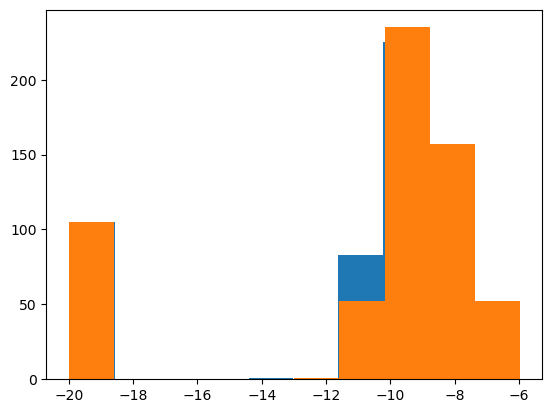

In [45]:
plt.hist(X_df['gp_kspace_log_band_powers_0'])
gp_band_powers = np.vstack(table["gp_kspace_log_band_powers"].to_numpy())
plt.hist(gp_band_powers[:, 1])

In [20]:
# from sklearn.decomposition import PCA

# X_np = X_train.detach().cpu().numpy()
# y_np = y_train.detach().cpu().numpy().flatten()

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_np)

# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)

# print(f"X_train shape: {X_np.shape}")
# print(f"n_components: {pca.n_components_}")
# print(f"Features: {feature_cols}")

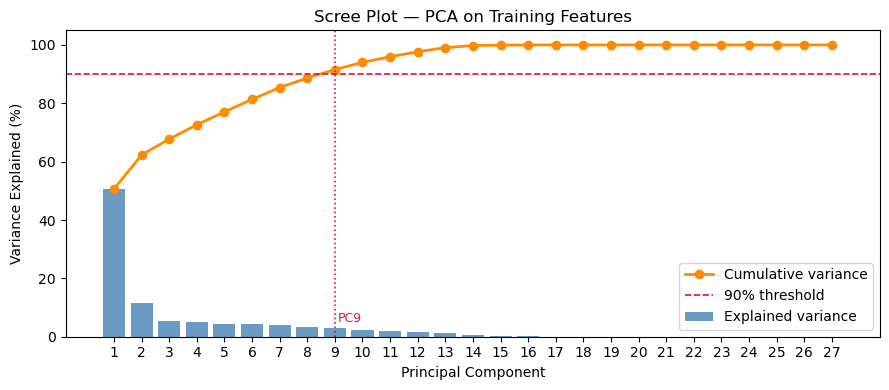

9 components explain ≥90% of variance  (91.5%)


In [21]:
# --- Cell 4: Scree Plot ---
evr = pca.explained_variance_ratio_
cumvar = np.cumsum(evr)
n_90 = np.searchsorted(cumvar, 0.90) + 1  # number of components for 90% variance

fig, ax = plt.subplots(figsize=(9, 4))
components = np.arange(1, len(evr) + 1)

ax.bar(components, evr * 100, color='steelblue', alpha=0.8, label='Explained variance')
ax.plot(components, cumvar * 100, 'o-', color='darkorange', lw=2, label='Cumulative variance')
ax.axhline(90, color='crimson', ls='--', lw=1.2, label='90% threshold')
ax.axvline(n_90, color='crimson', ls=':', lw=1.2)
ax.text(n_90 + 0.1, 5, f'PC{n_90}', color='crimson', fontsize=9)

ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Scree Plot — PCA on Training Features')
ax.set_xticks(components)
ax.legend()
plt.tight_layout()
plt.show()

print(f"{n_90} components explain ≥90% of variance  ({cumvar[n_90-1]*100:.1f}%)")

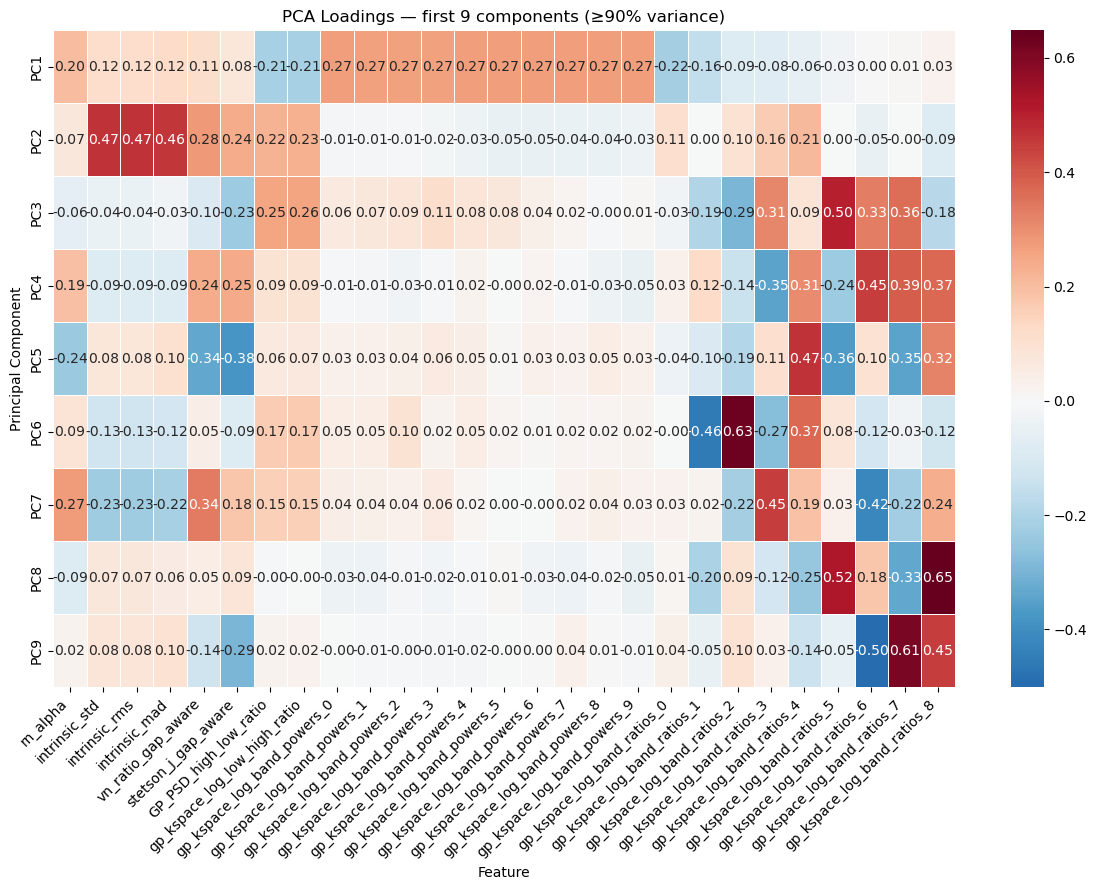

In [22]:
import seaborn as sns

# --- Cell 5: PCA Loadings Heatmap ---
loadings = pca.components_[:n_90, :]  # shape (n_90, n_features)

fig, ax = plt.subplots(figsize=(12, max(8, n_90 * 1)))
sns.heatmap(
    loadings,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    xticklabels=feature_cols,
    yticklabels=[f'PC{i+1}' for i in range(n_90)],
    linewidths=0.4,
    ax=ax,
)
ax.set_title(f'PCA Loadings — first {n_90} components (≥90% variance)')
ax.set_xlabel('Feature')
ax.set_ylabel('Principal Component')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

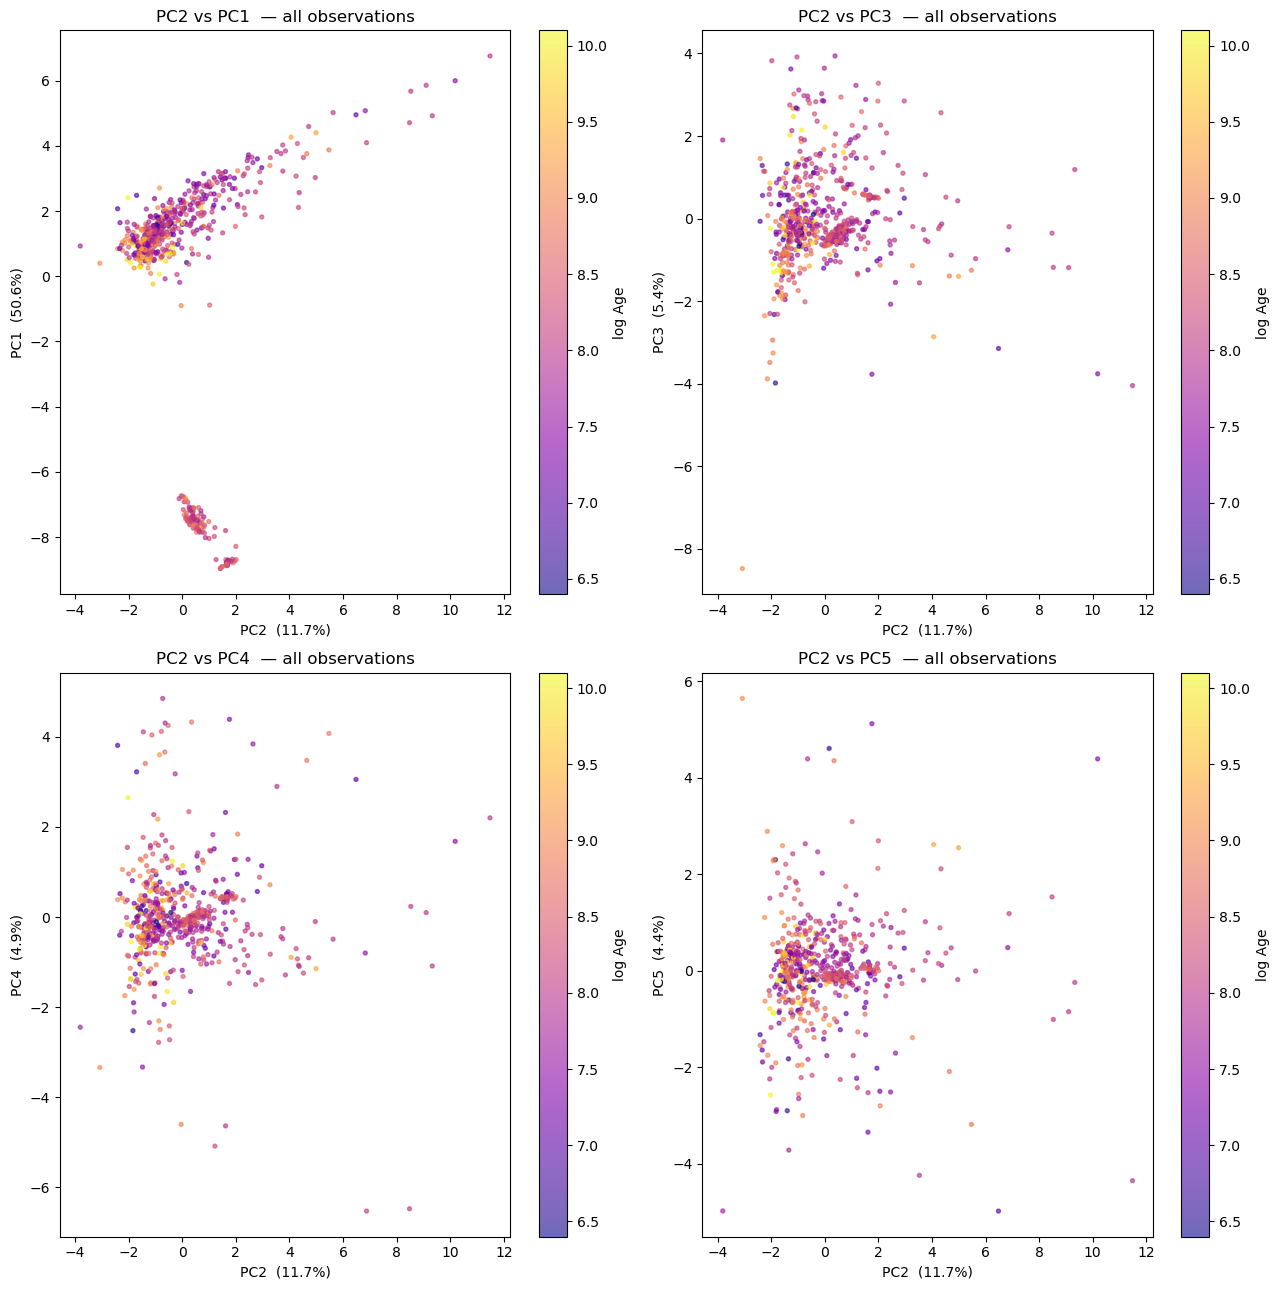

In [60]:
# --- Cell 6: Dataset in PCA Space (all observations, colored by age) ---
fig, axes = plt.subplots(2, 2, figsize=(13, 13))

for ax, (pc_x, pc_y) in zip(axes.flatten(), [(1, 0), (1, 2), (1, 3), (1, 4)]):
    sc = ax.scatter(X_pca[:, pc_x], X_pca[:, pc_y], c=y_np, cmap='plasma', s=8, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='log Age')
    ax.set_xlabel(f'PC{pc_x+1}  ({evr[pc_x]*100:.1f}%)')
    ax.set_ylabel(f'PC{pc_y+1}  ({evr[pc_y]*100:.1f}%)')
    ax.set_title(f'PC{pc_x+1} vs PC{pc_y+1}  — all observations')

plt.tight_layout()
plt.show()

In [58]:
#cluster_pca

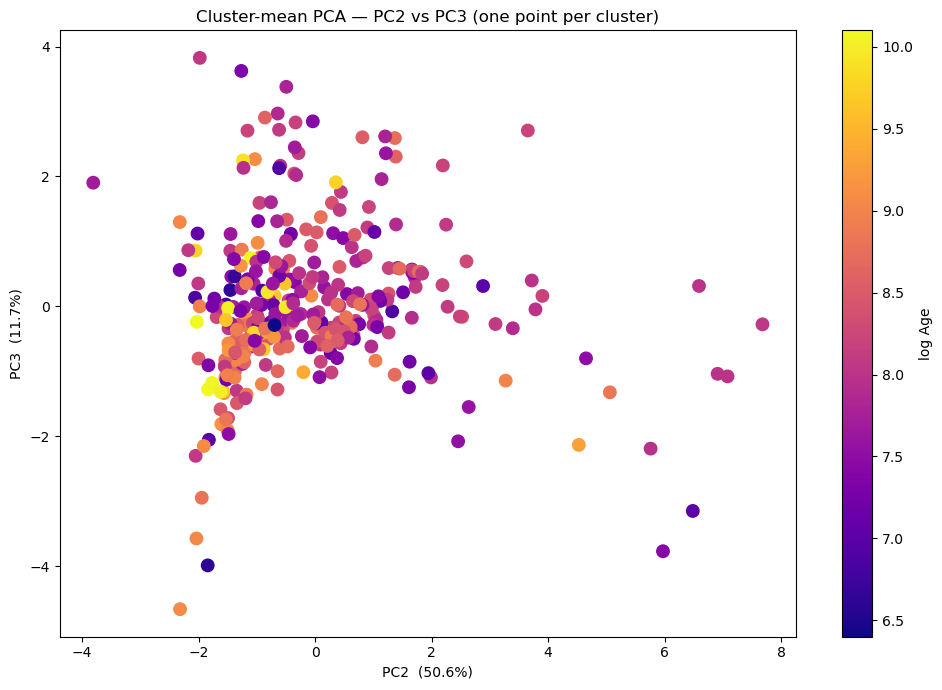

In [61]:
# --- Cell 7: Cluster-Level PCA (one point per cluster, colored by age) ---
train_cluster_names = table['name']
unique_clusters = np.unique(train_cluster_names)
pc_x = 1
pc_y = 2

cluster_means = np.array([X_scaled[train_cluster_names == c].mean(axis=0) for c in unique_clusters])
cluster_ages  = np.array([y_np[train_cluster_names == c].mean() for c in unique_clusters])
cluster_pca   = pca.transform(cluster_means)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(cluster_pca[:, pc_x], cluster_pca[:, pc_y], c=cluster_ages, cmap='plasma', s=80, zorder=3)
plt.colorbar(sc, ax=ax, label='log Age')

# for i, name in enumerate(unique_clusters):
#     ax.annotate(name, (cluster_pca[i, pc_x], cluster_pca[i, pc_y]),
#                 fontsize=7, xytext=(4, 3), textcoords='offset points')

ax.set_xlabel(f'PC{pc_x+1}  ({evr[0]*100:.1f}%)')
ax.set_ylabel(f'PC{pc_y+1}  ({evr[1]*100:.1f}%)')
ax.set_title(f'Cluster-mean PCA — PC{pc_x+1} vs PC{pc_y+1} (one point per cluster)')
plt.tight_layout()
plt.show()

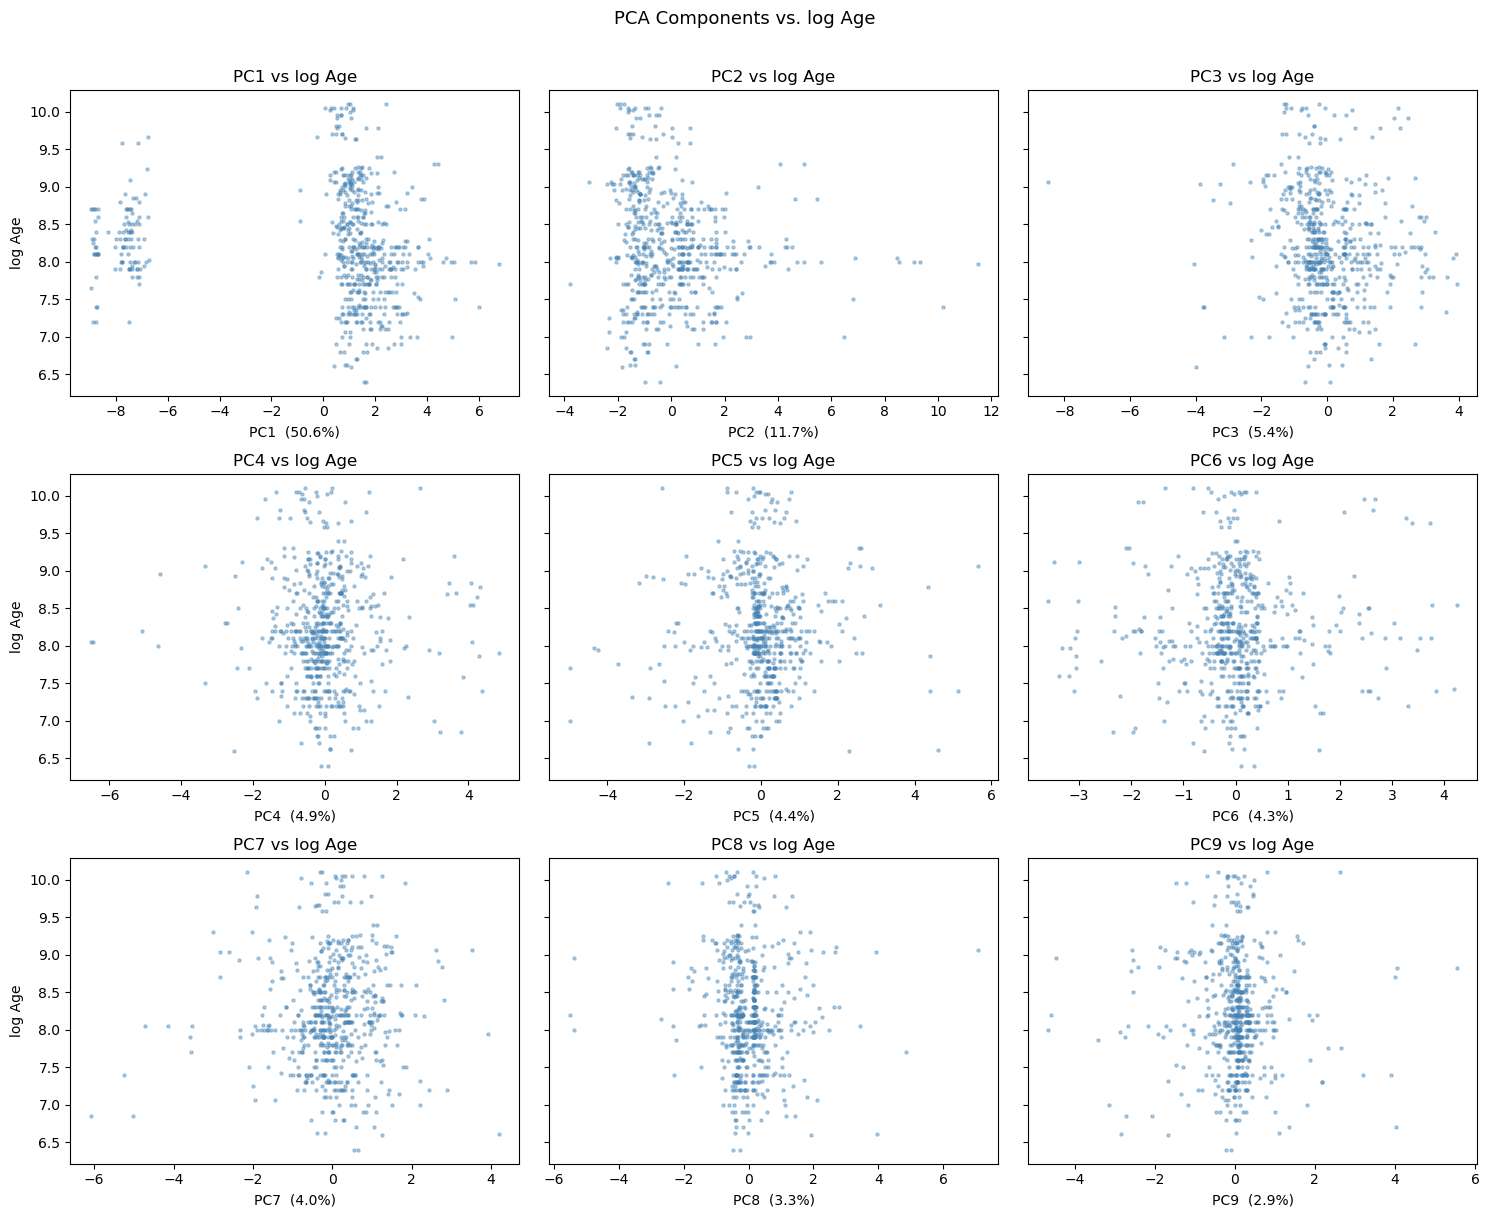

In [31]:
# --- Cell 8: Each PCA component vs. log Age ---
n_cols = 3
n_rows = int(np.ceil(n_90 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for i in range(n_90):
    ax = axes[i]
    ax.scatter(X_pca[:, i], y_np, s=5, alpha=0.4, color='steelblue')
    ax.set_xlabel(f'PC{i+1}  ({evr[i]*100:.1f}%)')
    ax.set_ylabel('log Age' if i % n_cols == 0 else '')
    ax.set_title(f'PC{i+1} vs log Age')

# Hide any unused subplots
for j in range(n_90, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('PCA Components vs. log Age', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

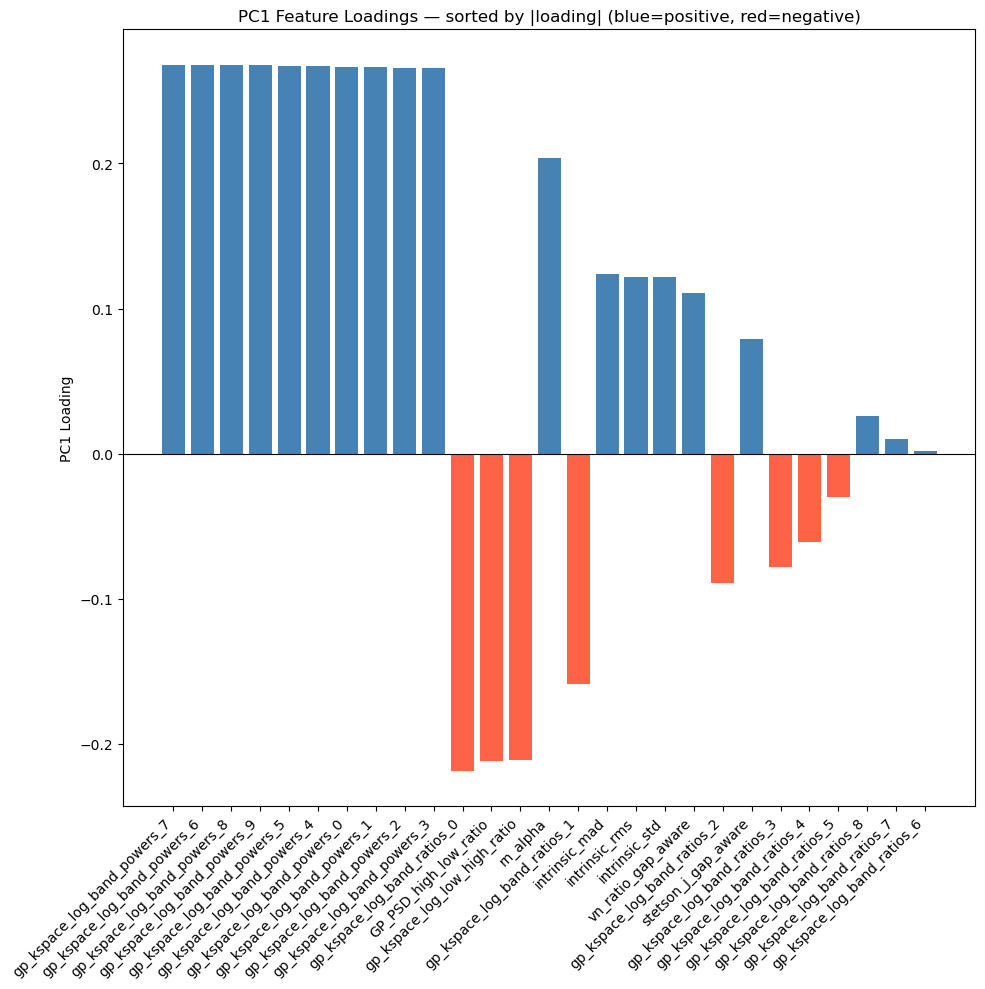

/tmp/ipykernel_646413/2769781507.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


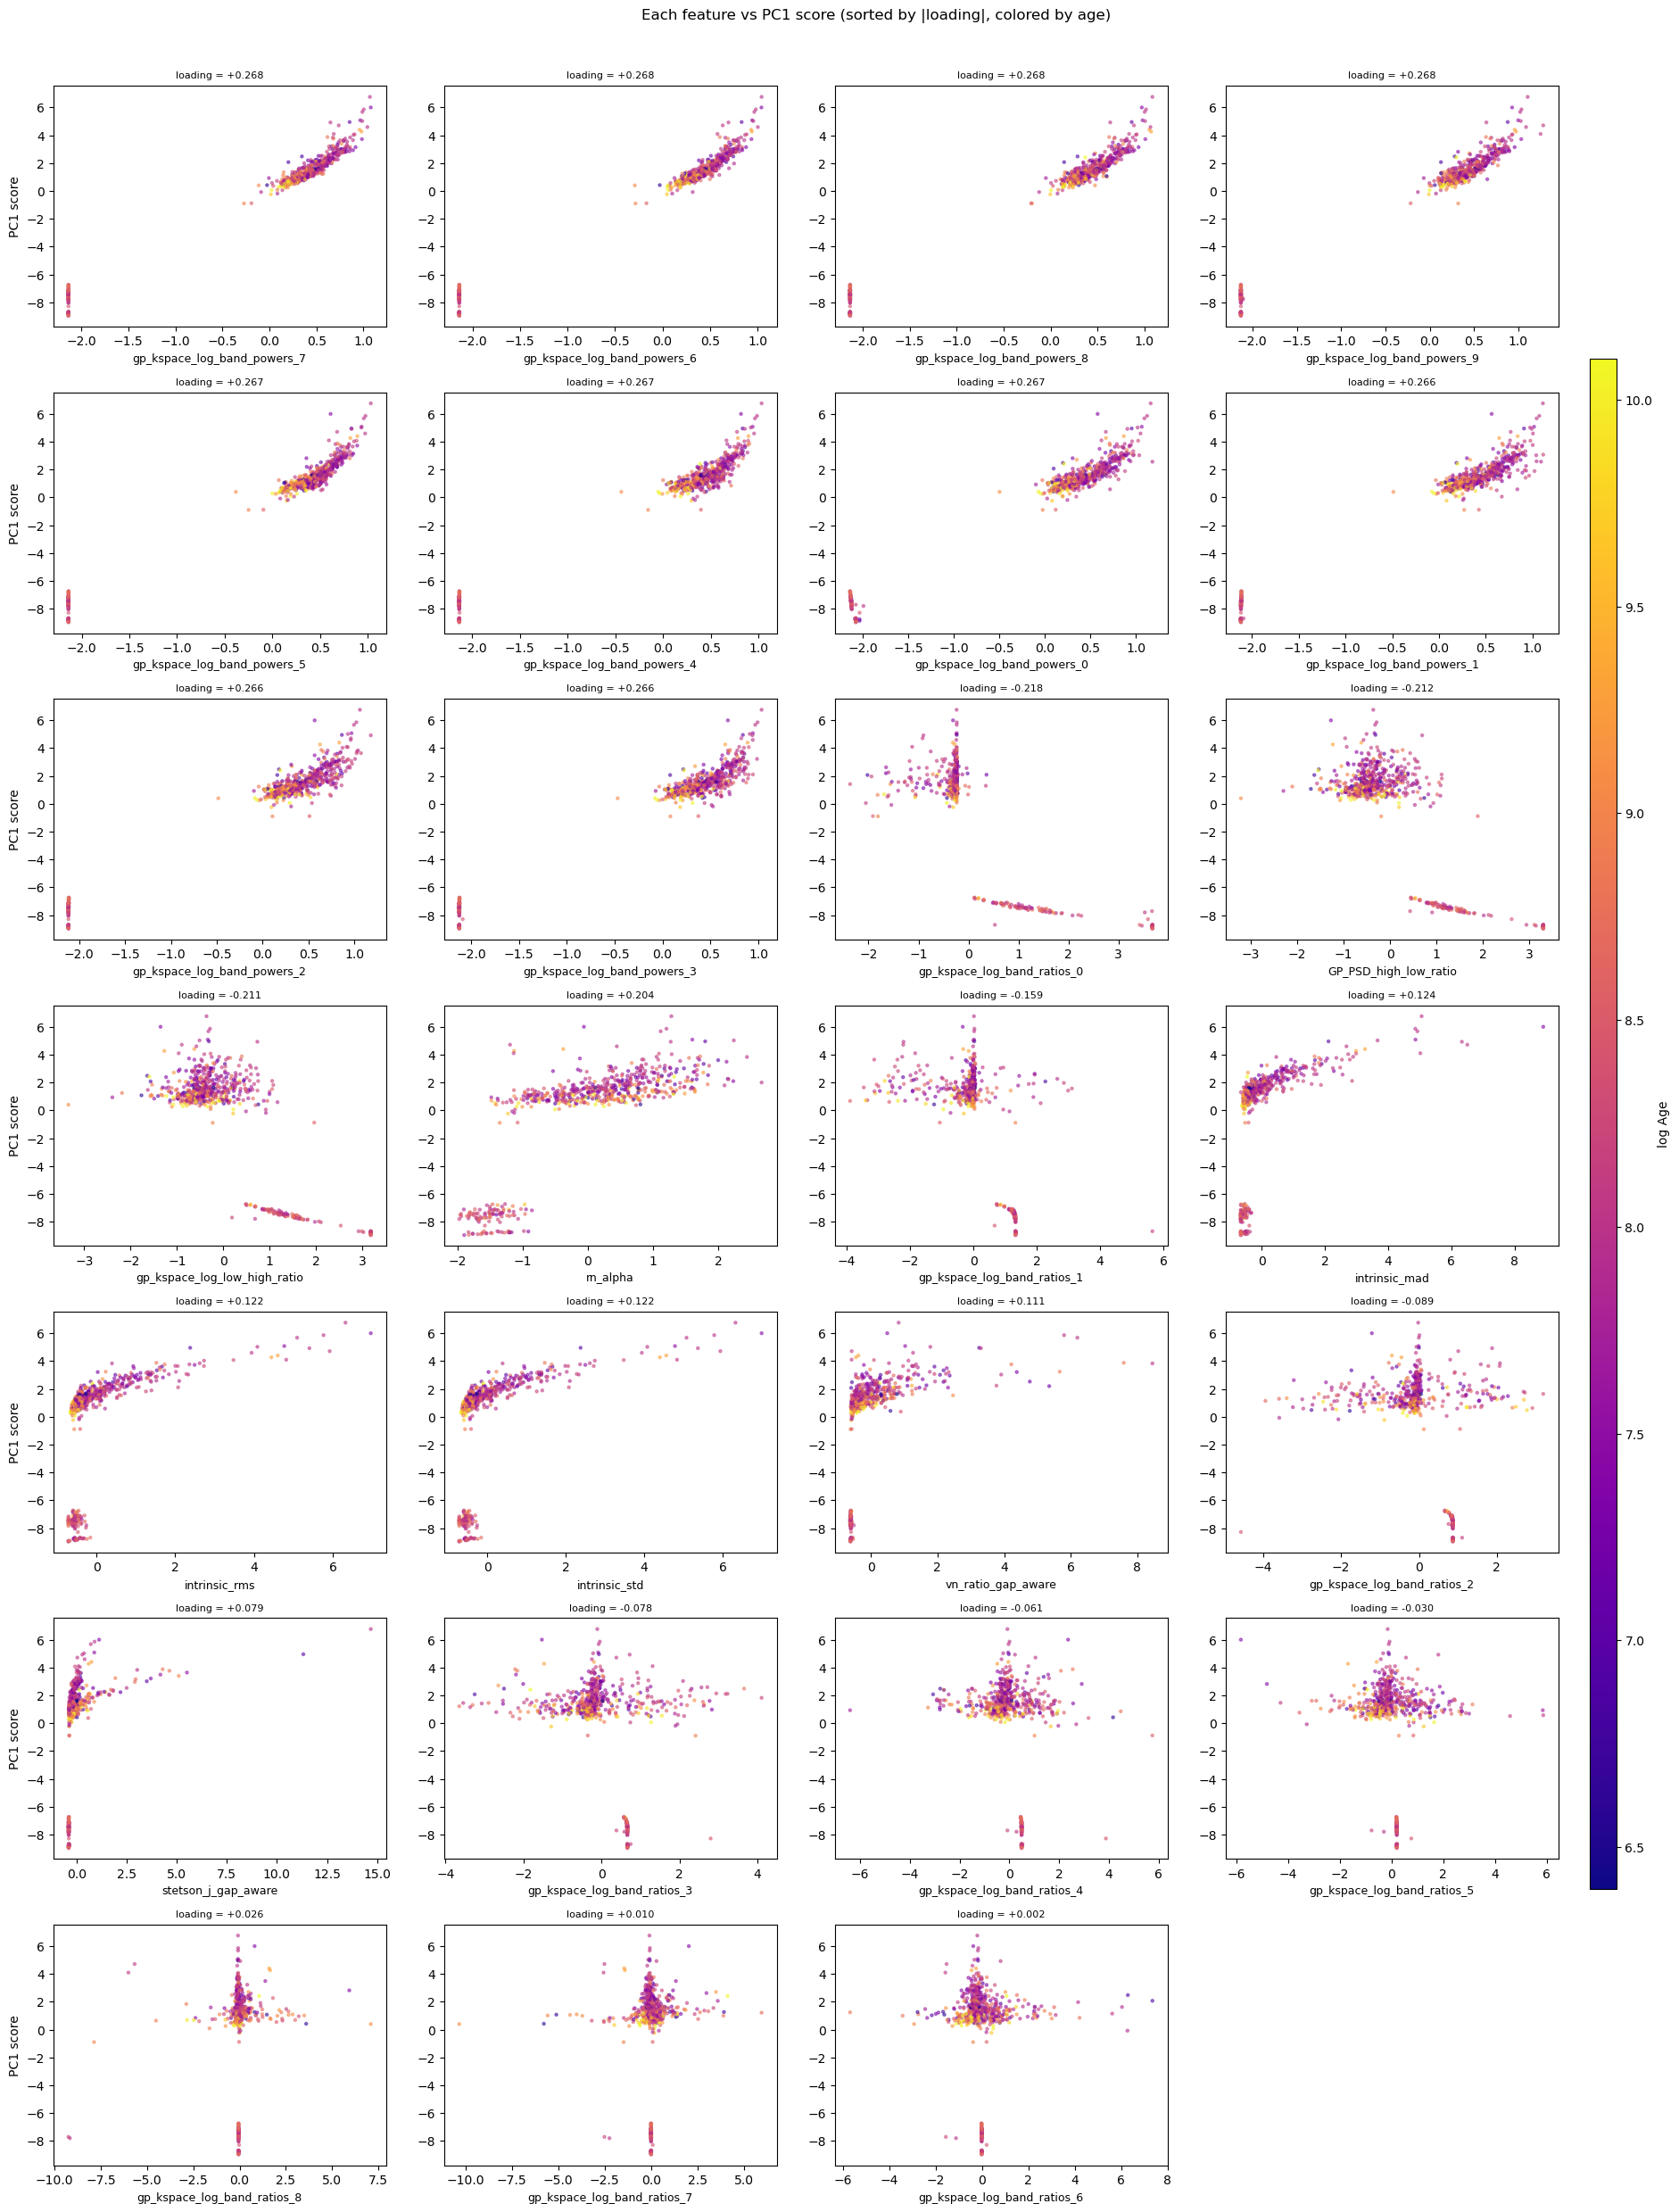

In [32]:
## --- Cell 9: PC1 Diagnostic — what drives the first component? ---
pc1_loadings = pca.components_[0]        # shape (n_features,)
pc1_scores   = X_pca[:, 0]              # shape (n_obs,)

# Sort features by absolute loading magnitude (largest driver first)
sort_idx = np.argsort(np.abs(pc1_loadings))[::-1]
sorted_features  = [feature_cols[i] for i in sort_idx]
sorted_loadings  = pc1_loadings[sort_idx]

# --- Top panel: loading bar chart ---
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if v > 0 else 'tomato' for v in sorted_loadings]
ax.bar(sorted_features, sorted_loadings, color=colors)
ax.axhline(0, color='k', lw=0.8)
ax.set_ylabel('PC1 Loading')
ax.set_title('PC1 Feature Loadings — sorted by |loading| (blue=positive, red=negative)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Bottom panel: each feature vs PC1 score, colored by age ---
n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for k, idx in enumerate(sort_idx):          # iterate in loading-magnitude order
    ax = axes[k]
    sc = ax.scatter(X_scaled[:, idx], pc1_scores, c=y_np, cmap='plasma', s=5, alpha=0.5)
    ax.set_xlabel(feature_cols[idx], fontsize=9)
    ax.set_ylabel('PC1 score' if k % n_cols == 0 else '')
    loading_val = pc1_loadings[idx]
    ax.set_title(f'loading = {loading_val:+.3f}', fontsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

# Single shared colorbar
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap='plasma',
                            norm=plt.Normalize(vmin=y_np.min(), vmax=y_np.max()))
fig.colorbar(sm, cax=cbar_ax, label='log Age')

fig.suptitle('Each feature vs PC1 score (sorted by |loading|, colored by age)', y=1.01, fontsize=12)
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()

/tmp/ipykernel_646413/3384758556.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.89, 1])


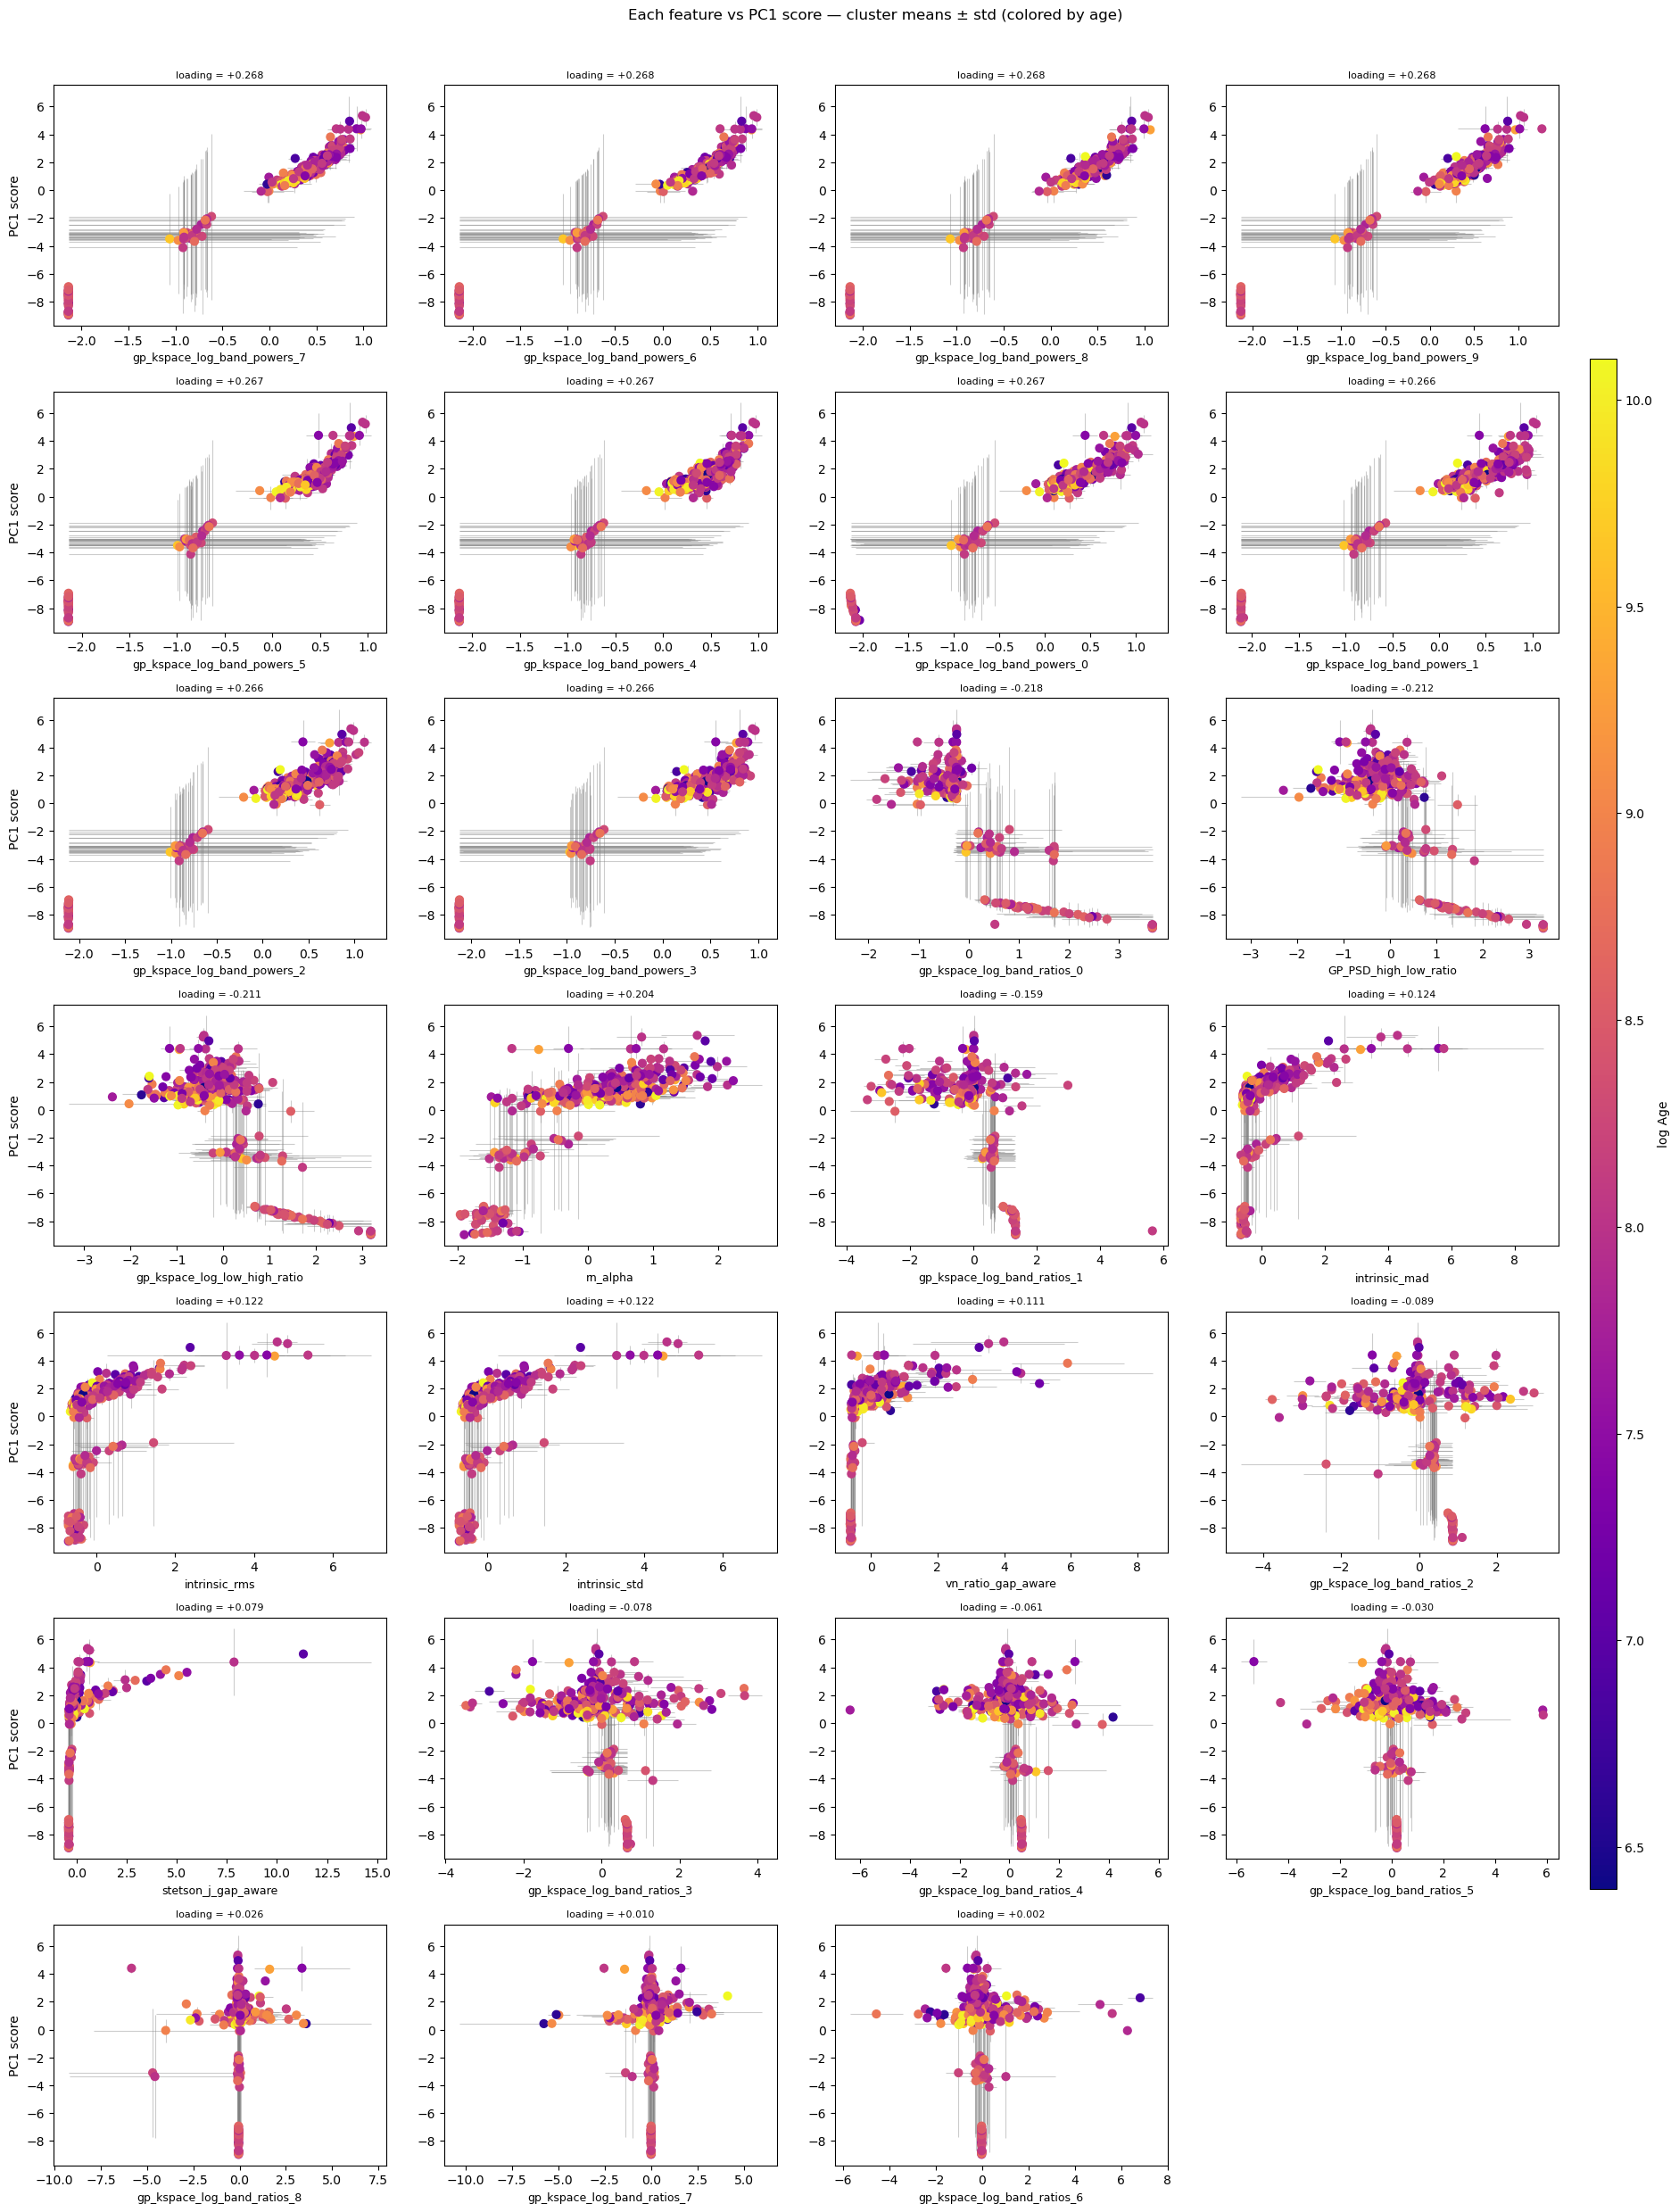

In [33]:
# --- Cell 10: PC1 Diagnostic — cluster-level (mean ± std per cluster) ---
unique_clusters = np.unique(train_cluster_names)

# Aggregate to per-cluster mean and std
c_feat_mean = np.array([X_scaled[train_cluster_names == c].mean(axis=0) for c in unique_clusters])  # (n_clusters, n_features)
c_feat_std  = np.array([X_scaled[train_cluster_names == c].std(axis=0)  for c in unique_clusters])
c_pc1_mean  = np.array([pc1_scores[train_cluster_names == c].mean()      for c in unique_clusters])
c_pc1_std   = np.array([pc1_scores[train_cluster_names == c].std()       for c in unique_clusters])
c_ages      = np.array([y_np[train_cluster_names == c].mean()            for c in unique_clusters])

norm_age = plt.Normalize(vmin=c_ages.min(), vmax=c_ages.max())
cmap     = plt.cm.plasma

n_cols = 4
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for k, idx in enumerate(sort_idx):      # same sort order as cell 9
    ax = axes[k]
    colors = cmap(norm_age(c_ages))

    ax.errorbar(
        c_feat_mean[:, idx], c_pc1_mean,
        xerr=c_feat_std[:, idx], yerr=c_pc1_std,
        fmt='none', ecolor='gray', alpha=0.4, lw=0.8, zorder=1,
    )
    sc = ax.scatter(c_feat_mean[:, idx], c_pc1_mean,
                    c=c_ages, cmap='plasma', s=40, zorder=2,
                    norm=norm_age)

    ax.set_xlabel(feature_cols[idx], fontsize=9)
    ax.set_ylabel('PC1 score' if k % n_cols == 0 else '')
    ax.set_title(f'loading = {pc1_loadings[idx]:+.3f}', fontsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7])
fig.colorbar(plt.cm.ScalarMappable(norm=norm_age, cmap='plasma'),
             cax=cbar_ax, label='log Age')

fig.suptitle('Each feature vs PC1 score — cluster means ± std (colored by age)', y=1.01, fontsize=12)
plt.tight_layout(rect=[0, 0, 0.89, 1])
plt.show()